In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from matplotlib.patches import Patch
from sklearn.ensemble import (
    ExtraTreesClassifier,
    RandomForestClassifier,
    VotingClassifier,
)
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import cross_val_score, train_test_split
from xgboost import XGBClassifier

optuna.logging.set_verbosity(optuna.logging.WARNING)
optuna.logging.set_verbosity(optuna.logging.ERROR)

# Retailer Churn Detection from Financial Transaction Data

In an increasingly competitive business landscape, customer retention has become a priority. **Churn** refers to the customer who stops transacting with a company. Early identification enables proactive strategic actions to prevent revenue loss.

**Problem Context**: Payments companies face retailer churn; each retailer that stops transacting represents direct revenue loss. Understanding pre-churn behavior patterns is essential for proactive retention strategies. A retailer is objectively defined as **Churn** when it does not perform any transaction within a 1-month period. The company uses anonymized data from a payments platform operating via link payments and POS/TEF terminals.

It is important to distinguish between **Loss** and **Churn**: a Loss is a month without transactions, while a Churn is a month without transactions *following* a Loss. Therefore, preventing Loss automatically prevents Churn.

The **objective** is to build a predictive model that, based on a retailer's transaction history, classifies them as likely Churn or Active, using advanced feature engineering techniques including calculus-based derivatives and z-scores.

*Note: The existing help-channel data had insufficient quality to predict churn, which motivated this time-series-based approach using transaction data directly.*

## Dataset Description

- **tx.csv** (Transactions):
  - `tx_id`: Unique transaction identifier
  - `tx_est_id`: Unique retailer/establishment identifier
  - `tx_date`: Transaction date and time
  - `tx_value_cents`: Transaction value in cents (converted to BRL)
  - `rec_est_status` / `churn`: Binary indicator of the retailer's status (Active vs Churn)

- **monthy_rec.csv** (Monthly Recurrence):
  - `rec_est_id`: Retailer identifier
  - `rec_monthly_category`: Monthly classification -- Recurring, Loss, Churn, Recovery, Never Transacted (translated from Portuguese at load time)
  - `rec_month`: Reference month

In [59]:
df_ts_tx_raw = pd.read_csv('./data/tx.csv')
df_ts_tx_raw['tx_date_date'] = pd.to_datetime(df_ts_tx_raw['tx_date']).dt.date
df_ts_tx_raw['tx_value'] = df_ts_tx_raw['tx_value_cents'] / 100

In [60]:
df_class = pd.read_csv('./data/monthy_rec.csv')

df_class = df_class[['rec_est_id', 'rec_monthly_category', 'rec_month']]
df_class.rename(
    columns={
        'rec_est_id': 'tx_est_id',
        'rec_monthly_category': 'churn',
        'rec_month': 'tx_date_month',
    },
    inplace=True,
)

category_map = {
    'Perda': 'Loss',
    'Recuperação': 'Recovery',
    'Recorrente': 'Recurring',
    'Nunca Mov': 'Never Transacted',
}
df_class['churn'] = df_class['churn'].replace(category_map)

df_class['churn_og'] = df_class['churn']
df_class = df_class.loc[~df_class['churn'].isin(['Never Transacted'])]

df_class['churn'] = np.where(
    df_class['churn'].isin(['Loss', 'Churn', 'Recovery']), '1', '0'
)
df_class['churn'] = df_class['churn'].astype(float)

df_class['tx_date_month'] = pd.to_datetime(df_class['tx_date_month'])
df_class['year_month'] = (
    df_class['tx_date_month'].dt.year.astype(str)
    + '-'
    + df_class['tx_date_month'].dt.month.astype(str).str.pad(2, fillchar='0')
)

# Exploratory Data Analysis

The first step is understanding how retailers are distributed by acquisition source. Internal test accounts were filtered out to avoid biasing the analysis.

### Churn and Loss Count Since 2023

Total number of unique retailers classified as Loss, Churn, or both from 2023 onwards. Since a Loss always precedes a Churn, the Loss count effectively defines how many retailers eventually churned.

In [61]:
perda_est_2023 = len(
    df_class.loc[
        (df_class['tx_date_month'].dt.year >= 2023)
        & df_class['churn_og'].isin(['Loss']),
        'tx_est_id',
    ].unique()
)
print(
    'Loss Count (it is this count that defines the number of'
    ' retailers that became Churns, given that before Churn'
    ' comes Losses)'
)
print(perda_est_2023)

churn_est_2023 = len(
    df_class.loc[
        (df_class['tx_date_month'].dt.year >= 2023)
        & df_class['churn_og'].isin(['Churn']),
        'tx_est_id',
    ].unique()
)
print(
    'Churn Count (count not very effective for analysis as there'
    ' is an accumulation of Churns from other years)'
)
print(churn_est_2023)

churn_perda_est_2023 = len(
    df_class.loc[
        (df_class['tx_date_month'].dt.year >= 2023)
        & df_class['churn_og'].isin(['Churn', 'Loss']),
        'tx_est_id',
    ].unique()
)
print('Counting Churns and Losses')
print(churn_perda_est_2023)

Loss Count (it is this count that defines the number of retailers that became Churns, given that before Churn comes Losses)
3513
Churn Count (count not very effective for analysis as there is an accumulation of Churns from other years)
6147
Counting Churns and Losses
6714


### Monthly Churn Distribution

Count of Loss and Recurring retailers per month from 2023 onwards, showing how churn events are distributed over time.

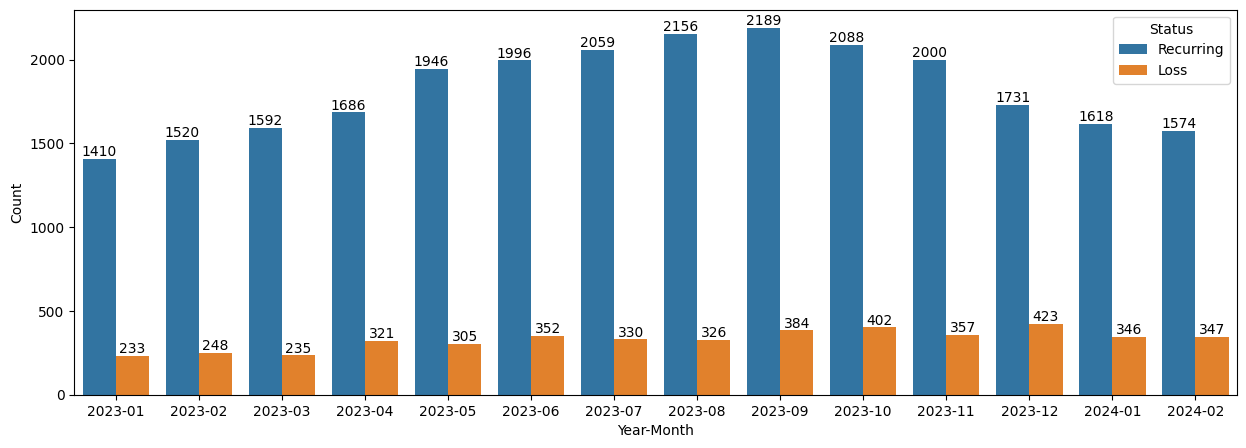

In [62]:
plot_data = df_class.loc[
    (df_class['tx_date_month'].dt.year >= 2023)
    & df_class['churn_og'].isin(['Loss', 'Recurring'])
].copy()
cnt_plt = sns.countplot(
    x='year_month', hue='churn_og',
    data=plot_data.sort_values(by='year_month'),
)
cnt_plt.bar_label(cnt_plt.containers[0])
cnt_plt.bar_label(cnt_plt.containers[1])
cnt_plt.figure.set_size_inches(15, 5)
plt.xlabel('Year-Month')
plt.ylabel('Count')
plt.legend(title='Status')
plt.show()

### Monthly Transaction Volume of Churned Retailers

Aggregated transaction value per month for retailers that experienced Loss from 2023 onwards, illustrating the financial magnitude of churn over time.

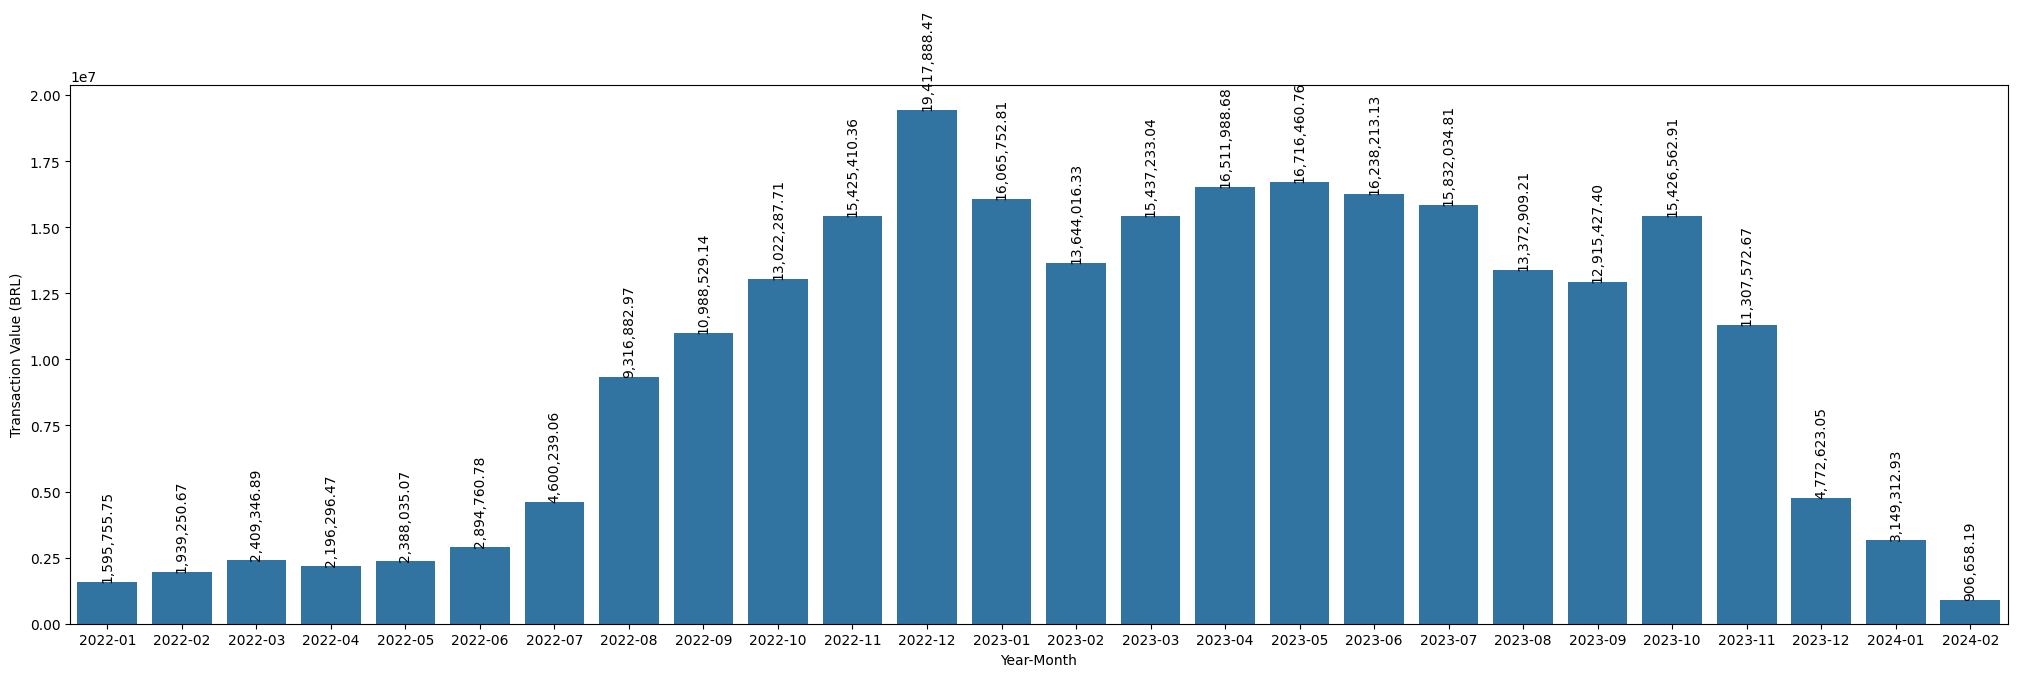

In [63]:
df_est_sum_month = df_ts_tx_raw.copy()
df_est_sum_month['tx_date_date'] = pd.to_datetime(
    df_est_sum_month['tx_date_date']
)
df_est_sum_month['year_month'] = (
    df_est_sum_month['tx_date_date'].dt.year.astype(str)
    + '-'
    + df_est_sum_month['tx_date_date'].dt.month.astype(str).str.pad(
        2, fillchar='0'
    )
)
df_est_sum_month = df_est_sum_month.groupby(
    ['tx_est_id', 'year_month'], as_index=False
)['tx_value'].sum()

ests_churns_2023 = df_class.loc[
    (df_class['tx_date_month'].dt.year >= 2023)
    & df_class['churn_og'].isin(['Loss']),
    'tx_est_id',
].unique()

df_mf_chr = (
    df_est_sum_month[df_est_sum_month['tx_est_id'].isin(ests_churns_2023)]
    .groupby('year_month', as_index=False)['tx_value']
    .sum()
)

df_mf_chr_sorted = df_mf_chr.sort_values(by='year_month')
cnt_plt = sns.barplot(
    x='year_month', y='tx_value', data=df_mf_chr_sorted,
)
cnt_plt.bar_label(
    cnt_plt.containers[0],
    labels=[f'{x:,.2f}' for x in df_mf_chr_sorted['tx_value']],
    fontsize=10,
    rotation='vertical',
)
cnt_plt.figure.set_size_inches(25, 7)
plt.xlabel('Year-Month')
plt.ylabel('Transaction Value (BRL)')
plt.show()

### Quality of Help-Channel Data

A critical aspect of the analysis is demonstrating that the pre-existing support data was unreliable for churn prediction. The efficiency variable is calculated as:
$$\text{efficiency} = \frac{\text{establishment\_lifetime}}{\text{establishment\_lifetime} + \text{service\_request\_count}}$$

A value of -1 indicates no match was found between a service request and a retailer. The match rate between support requests and retailers is extremely low, confirming that the help-channel data is **not reliable for predicting churn**. This motivates the approach proposed in this project: **using the retailers' transactional data directly** to build predictive features.

### Average Monthly Transaction Volume: Active vs. Churn

Comparison of the mean monthly transaction value between retailers classified as Loss/Churn and those that remained Active, highlighting the behavioral gap between the two groups.

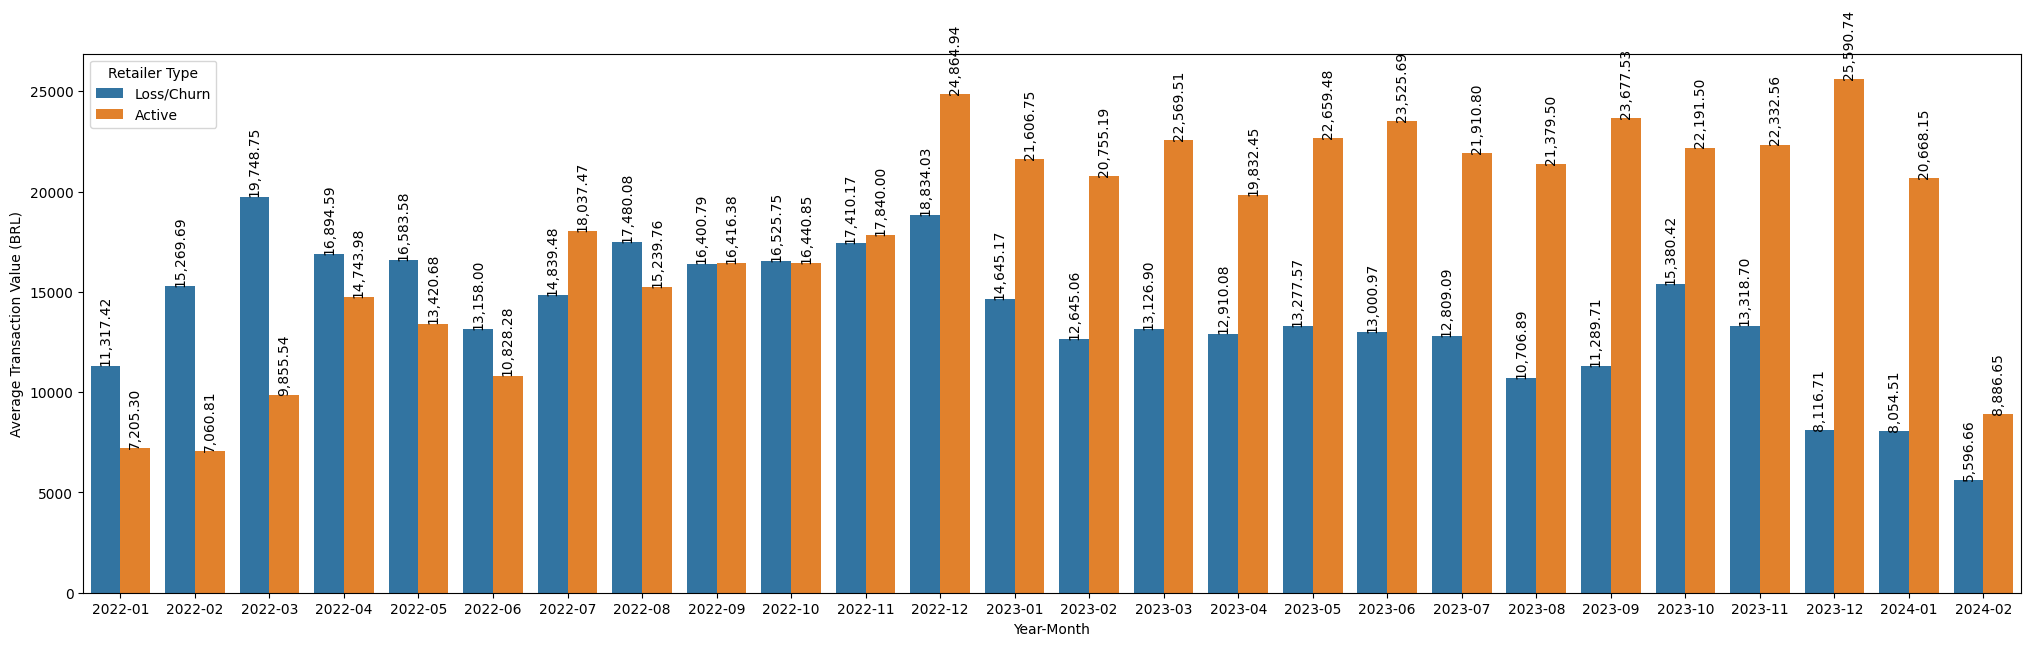

In [64]:
ests_churns_2023 = df_class.loc[
    (df_class['tx_date_month'].dt.year >= 2023)
    & df_class['churn_og'].isin(['Loss']),
    'tx_est_id',
].unique()

mf_churn = (
    df_est_sum_month[df_est_sum_month['tx_est_id'].isin(ests_churns_2023)]
    .groupby('year_month', as_index=False)['tx_value']
    .mean()
)
mf_ativo = (
    df_est_sum_month[~df_est_sum_month['tx_est_id'].isin(ests_churns_2023)]
    .groupby('year_month', as_index=False)['tx_value']
    .mean()
)

mf_churn['type'] = 'Loss/Churn'
mf_ativo['type'] = 'Active'

df_comp = pd.concat([mf_churn, mf_ativo])
df_comp_sorted = df_comp.sort_values(by='year_month')

cnt_plt = sns.barplot(
    x='year_month', y='tx_value', hue='type', data=df_comp_sorted,
)
churn_labels = df_comp_sorted.loc[
    df_comp_sorted['type'] == 'Loss/Churn', 'tx_value'
]
active_labels = df_comp_sorted.loc[
    df_comp_sorted['type'] == 'Active', 'tx_value'
]
cnt_plt.bar_label(
    cnt_plt.containers[0],
    labels=[f'{x:,.2f}' for x in churn_labels],
    fontsize=10, rotation='vertical',
)
cnt_plt.bar_label(
    cnt_plt.containers[1],
    labels=[f'{x:,.2f}' for x in active_labels],
    fontsize=10, rotation='vertical',
)
cnt_plt.figure.set_size_inches(25, 7)
plt.xlabel('Year-Month')
plt.ylabel('Average Transaction Value (BRL)')
plt.legend(title='Retailer Type')
plt.show()

### Accumulated Revenue Loss

Total revenue processed by retailers that eventually churned since 2023, representing the cumulative financial impact of churn.

In [65]:
total_loss_brl = df_est_sum_month.loc[
    df_est_sum_month['tx_est_id'].isin(ests_churns_2023),
    'tx_value',
].sum()
print(f'R$ {total_loss_brl:,.2f}')

R$ 258,491,449.26


### Retailer Count (Raw)

Total number of unique retailers in the raw transaction dataset, before any filtering or treatment.

In [66]:
len(df_ts_tx_raw['tx_est_id'].unique())

8843

In [67]:
df_ts_tx_raw.sort_values(by=['tx_est_id', 'tx_date'], inplace=True)

# Time Series Analysis and Feature Engineering

In [68]:
def until_last_loss(df: pd.DataFrame) -> pd.DataFrame:
    """Truncate a retailer's data up to the first loss transition.

    If the last row is labelled as churn (1), returns the slice up to
    and including the first transition from active (0) to loss (1).
    Otherwise returns the full DataFrame unchanged.

    Parameters
    ----------
    df : pd.DataFrame
        Single-retailer DataFrame containing a 'churn' column.

    Returns
    -------
    pd.DataFrame
        Truncated or full DataFrame depending on churn status.
    """
    df = df.reset_index(drop=True)
    if df.iloc[-1]['churn'] == 1:
        transition_idx = np.where(
            (df['churn'] == 1)
            & (df['churn'].shift(1) == 0)
            & df['churn'].shift(1).notna(),
            df.index,
            0,
        ).max() + 1
        return df.iloc[:transition_idx]
    return df

In [69]:
df_ts_tx_raw.groupby('tx_est_id').apply(until_last_loss).reset_index(level=0)

,tx_est_id,tx_id,tx_date,tx_value_cents,churn,tx_date_date,tx_value
0,49,8690153,2022-01-16 09:37:59.000,1400,0,2022-01-16,14.00
1,49,8690189,2022-01-16 09:57:31.000,5800,0,2022-01-16,58.00
2,49,8690519,2022-01-16 12:00:11.000,16000,0,2022-01-16,160.00
3,49,8690529,2022-01-16 12:03:54.000,2900,0,2022-01-16,29.00
4,49,8690603,2022-01-16 12:32:47.000,2200,0,2022-01-16,22.00
...,...,...,...,...,...,...,...
274,39531,15477399,2024-02-13 22:47:34.000,19290,0,2024-02-13,192.90
275,39531,15477404,2024-02-13 22:48:59.000,18438,0,2024-02-13,184.38
0,39534,15312580,2024-01-30 08:22:39.000,1985500,0,2024-01-30,19855.00
0,39547,15377024,2024-02-04 23:27:20.000,200000,0,2024-02-04,2000.00


In [70]:
df_ts_tx_raw_until_last_loss = (
    df_ts_tx_raw.groupby('tx_est_id')
    .apply(until_last_loss)
    .reset_index(level=0)
)

df_ts_tx_raw_until_last_loss.sort_values(
    by=['tx_est_id', 'tx_date'], inplace=True
)
df_ts_tx_raw_until_last_loss

,tx_est_id,tx_id,tx_date,tx_value_cents,churn,tx_date_date,tx_value
0,49,8690153,2022-01-16 09:37:59.000,1400,0,2022-01-16,14.00
1,49,8690189,2022-01-16 09:57:31.000,5800,0,2022-01-16,58.00
2,49,8690519,2022-01-16 12:00:11.000,16000,0,2022-01-16,160.00
3,49,8690529,2022-01-16 12:03:54.000,2900,0,2022-01-16,29.00
4,49,8690603,2022-01-16 12:32:47.000,2200,0,2022-01-16,22.00
...,...,...,...,...,...,...,...
274,39531,15477399,2024-02-13 22:47:34.000,19290,0,2024-02-13,192.90
275,39531,15477404,2024-02-13 22:48:59.000,18438,0,2024-02-13,184.38
0,39534,15312580,2024-01-30 08:22:39.000,1985500,0,2024-01-30,19855.00
0,39547,15377024,2024-02-04 23:27:20.000,200000,0,2024-02-04,2000.00


### Retailer Selection Criteria

Each retailer is evaluated based on whether they are or have been classified as Churn, along with their day count and transaction count. This step identifies which retailers meet the criteria for further time series analysis.

In [71]:
df_ts_tx_raw_until_last_loss['tx_date'] = pd.to_datetime(
    df_ts_tx_raw_until_last_loss['tx_date'], format='ISO8601'
).dt.date
df_ts_tx_raw_until_last_loss

,tx_est_id,tx_id,tx_date,tx_value_cents,churn,tx_date_date,tx_value
0,49,8690153,2022-01-16,1400,0,2022-01-16,14.00
1,49,8690189,2022-01-16,5800,0,2022-01-16,58.00
2,49,8690519,2022-01-16,16000,0,2022-01-16,160.00
3,49,8690529,2022-01-16,2900,0,2022-01-16,29.00
4,49,8690603,2022-01-16,2200,0,2022-01-16,22.00
...,...,...,...,...,...,...,...
274,39531,15477399,2024-02-13,19290,0,2024-02-13,192.90
275,39531,15477404,2024-02-13,18438,0,2024-02-13,184.38
0,39534,15312580,2024-01-30,1985500,0,2024-01-30,19855.00
0,39547,15377024,2024-02-04,200000,0,2024-02-04,2000.00


In [72]:
df_churn_check = df_ts_tx_raw_until_last_loss.groupby(
    'tx_est_id', as_index=False
).agg(
    churn_check=('churn', 'sum'),
    day_count=('tx_date', 'nunique'),
    tx_count=('tx_id', 'count'),
)

df_churn_check['tx_per_day'] = (
    df_churn_check['tx_count'] / df_churn_check['day_count']
)

for chrn in [0, 1]:
    for col_name in ['day_count', 'tx_count', 'tx_per_day']:
        print(
            f'Top 10 retailers with Churn =={chrn} ({col_name})'
        )
        df_it = (
            df_churn_check[df_churn_check['churn_check'] == chrn]
            .sort_values(by=col_name, ascending=False)
            .head(10)
        )
        display(df_it)
        print(df_it['tx_est_id'].tolist())

Top 10 retailers with Churn ==0 (day_count)


,tx_est_id,churn_check,day_count,tx_count,tx_per_day
2230,20681,0,740,37615,50.831081
1109,13042,0,740,43104,58.248649
256,4971,0,736,27313,37.110054
162,3655,0,693,24419,35.236652
2836,22281,0,658,48443,73.621581
2852,22318,0,655,21893,33.424427
2547,21608,0,646,2861,4.428793
2467,21414,0,642,23594,36.750779
1867,19037,0,634,6257,9.869085
2086,20068,0,629,3686,5.860095


[20681, 13042, 4971, 3655, 22281, 22318, 21608, 21414, 19037, 20068]
Top 10 retailers with Churn ==0 (tx_count)


,tx_est_id,churn_check,day_count,tx_count,tx_per_day
6458,31905,0,307,63022,205.283388
4020,27021,0,535,60124,112.381308
5194,29152,0,433,58671,135.498845
7390,34810,0,236,50148,212.491525
312,5519,0,353,49553,140.376771
2836,22281,0,658,48443,73.621581
5938,30582,0,248,46420,187.177419
4065,27082,0,545,46251,84.864220
4816,28466,0,467,45112,96.599572
2751,22060,0,620,44905,72.427419


[31905, 27021, 29152, 34810, 5519, 22281, 30582, 27082, 28466, 22060]
Top 10 retailers with Churn ==0 (tx_per_day)


...

[7221, 29056, 26629, 26413, 10406, 28107, 29661, 7391, 27188, 34534]
Top 10 retailers with Churn ==1 (tx_count)


,tx_est_id,churn_check,day_count,tx_count,tx_per_day
3784,26629,1,217,10765,49.608295
7257,34534,1,86,6142,71.418605
5148,29056,1,231,5490,23.766234
5075,28927,1,77,2701,35.077922
3684,26413,1,198,2539,12.823232
426,7221,1,429,2195,5.116550
7185,34394,1,57,1719,30.157895
6313,31581,1,62,1641,26.467742
5240,29245,1,19,1470,77.368421
5439,29661,1,103,1341,13.019417


[26629, 34534, 29056, 28927, 26413, 7221, 34394, 31581, 29245, 29661]
Top 10 retailers with Churn ==1 (tx_per_day)


,tx_est_id,churn_check,day_count,tx_count,tx_per_day
5240,29245,1,19,1470,77.368421
7257,34534,1,86,6142,71.418605
3784,26629,1,217,10765,49.608295
5075,28927,1,77,2701,35.077922
7185,34394,1,57,1719,30.157895
6313,31581,1,62,1641,26.467742
5148,29056,1,231,5490,23.766234
5733,30201,1,71,966,13.605634
6713,32354,1,37,489,13.216216
5439,29661,1,103,1341,13.019417


[29245, 34534, 26629, 28927, 34394, 31581, 29056, 30201, 32354, 29661]


### Selected Retailers for Behavioral Analysis

A representative sample of retailers was selected to observe typical transaction patterns for each class.

- **Churn**:
[29056, 32354, 26629, 10406, 34534, 32810, 31581, 26413, 37072, 30201, 34394, 29661, 7391]
 
- **Active**:
[32001, 36485, 22281, 21754, 27021, 5519, 33679, 37406, 31905, 21414, 22060, 22318, 28466, 3655, 20681, 27082, 37070, 19037, 32606, 29152, 21608, 4971, 13042, 30582, 34810]

The following count and percentage difference features are engineered from the daily transaction data: `tx_sum` (total daily transaction sum), `tx_cum_count_per_day` (cumulative transaction count per transacted day), `tx_cum_count` (total cumulative transaction count), `tx_cum_sum` (cumulative sum of transaction values), and `tx_cum_sum_per_day` (cumulative sum per transacted day).

$$\text{tx\_cum\_count\_per\_day}_t = \frac{\sum_{i=1}^{t} \text{tx\_count}_i}{\text{days\_transacted}_t}$$

The percentage difference between consecutive observations is also computed:
$$\Delta\%_t = \frac{x_t - x_{t-1}}{x_{t-1}}$$

In [73]:
df_feat = df_ts_tx_raw_until_last_loss.copy()

df_ts_tx_mf_day = df_feat.groupby(
    ['tx_est_id', 'tx_date_date'], as_index=False
).agg(
    tx_sum=('tx_value', 'sum'),
    tx_count=('tx_id', 'nunique'),
)

df_ts_tx_mf_day['tx_cum_sum'] = (
    df_ts_tx_mf_day.groupby('tx_est_id')['tx_sum'].cumsum()
)
df_ts_tx_mf_day['tx_cum_count'] = (
    df_ts_tx_mf_day.groupby('tx_est_id')['tx_count'].cumsum()
)

df_feat['cumul_day_count'] = (
    (~df_feat[['tx_est_id', 'tx_date_date']].duplicated())
    .groupby(df_feat['tx_est_id'])
    .cumsum()
)

df_feat = df_feat.merge(
    df_ts_tx_mf_day, on=['tx_est_id', 'tx_date_date'], how='inner'
)

df_feat['tx_cum_count_per_day'] = (
    df_feat['tx_cum_count'] / df_feat['cumul_day_count']
)
df_feat['tx_cum_sum_per_day'] = (
    df_feat['tx_cum_sum'] / df_feat['cumul_day_count']
)

df_feat = df_feat[[
    'tx_est_id', 'tx_date_date', 'churn', 'cumul_day_count',
    'tx_sum', 'tx_count', 'tx_cum_sum', 'tx_cum_count',
    'tx_cum_count_per_day', 'tx_cum_sum_per_day',
]].drop_duplicates()

df_perc_change = df_feat.groupby('tx_est_id').agg(
    tx_sum_pct_chg=('tx_sum', 'pct_change'),
    tx_count_pct_chg=('tx_count', 'pct_change'),
    tx_cum_sum_pct_chg=('tx_cum_sum', 'pct_change'),
    tx_cum_count_pct_chg=('tx_cum_count', 'pct_change'),
    tx_cum_count_per_day_pct_chg=('tx_cum_count_per_day', 'pct_change'),
    tx_cum_sum_per_day_pct_chg=('tx_cum_sum_per_day', 'pct_change'),
)

df_feat = pd.concat([df_feat, df_perc_change], axis=1)

df_feat['tx_date_date'] = pd.to_datetime(df_feat['tx_date_date'])

df_feat['year_week'] = (
    df_feat['tx_date_date']
    - pd.TimedeltaIndex(
        pd.to_timedelta(df_feat['tx_date_date'].dt.dayofweek + 1, unit='D')
    )
)
df_feat.fillna(0, inplace=True)
df_feat['year_week'] = df_feat['year_week'].dt.date

Daily data is then grouped by week (`year_week`), producing `tx_sum`, `tx_day_count`, and `tx_sum_per_day`. Only retailers with 12+ transacted weeks are kept.

$$\text{tx\_sum\_per\_day} = \frac{\text{tx\_sum}}{\text{tx\_day\_count}}$$

In [74]:
df_feat_week = df_feat.copy()
df_feat_week = df_feat_week.groupby(
    ['tx_est_id', 'year_week'], as_index=False
).agg(
    tx_sum=('tx_sum', 'sum'),
    tx_day_count=('tx_date_date', 'nunique'),
)
df_feat_week['tx_sum_per_day'] = (
    df_feat_week['tx_sum'] / df_feat_week['tx_day_count']
)

df_feat_week = df_feat_week.groupby('tx_est_id').filter(
    lambda x: len(x) >= 12
)

df_feat_week = df_feat_week.merge(
    df_feat[['tx_est_id', 'year_week', 'churn']].drop_duplicates(),
    on=['tx_est_id', 'year_week'],
    how='inner',
)

df_feat_week

,tx_est_id,year_week,tx_sum,tx_day_count,tx_sum_per_day,churn
0,89,2022-01-02,1787.00,3,595.666667,0
1,89,2022-01-09,239.00,3,79.666667,0
2,89,2022-01-16,280.00,2,140.000000,0
3,89,2022-01-23,685.00,3,228.333333,0
4,89,2022-01-30,2208.00,4,552.000000,0
...,...,...,...,...,...,...
112917,38756,2024-01-14,14866.29,7,2123.755714,0
112918,38756,2024-01-21,12260.21,6,2043.368333,0
112919,38756,2024-01-28,15756.34,6,2626.056667,0
112920,38756,2024-02-04,13860.23,7,1980.032857,0


In [75]:
def split_condition(first, last):
    """Check if a transition from active to churn occurred.

    Parameters
    ----------
    first : int or float
        Label value at the start of the segment.
    last : int or float
        Label value of the current row.

    Returns
    -------
    bool
        True if the segment starts active (0) and ends in churn (1).
    """
    return (first == 0) & (last == 1)


def split_dataframe(df, label_col: str = 'churn',
                    id_col: str = 'tx_est_id'):
    """Split a retailer's weekly series into active-to-loss chunks.

    Fills missing weeks with zeros (gap insertion) and assigns a
    sequential chunk identifier to each segment.

    Parameters
    ----------
    df : pd.DataFrame
        Single-retailer DataFrame with 'year_week', label, and id columns.
    label_col : str, optional
        Churn/label column name. Default is 'churn'.
    id_col : str, optional
        Retailer identifier column name. Default is 'tx_est_id'.

    Returns
    -------
    pd.DataFrame
        Concatenated chunks with an additional 'chunk_it' column.
    """
    chunks = []
    id_est = df[id_col].values[0]
    df = (
        df.sort_values('year_week')
        .drop_duplicates(subset='year_week', keep='last')
        .set_index('year_week')
        .asfreq('W')
        .fillna(0)
        .reset_index()
    )
    df[id_col] = id_est

    start_index = 0
    end_index = 0
    chunk_counter = 0
    for i, row in df.iterrows():
        if i == start_index:
            end_index = i
        if split_condition(
            df.iloc[start_index][label_col], row[label_col]
        ):
            chunk = df.iloc[start_index:end_index + 1].copy()
            chunk['chunk_it'] = chunk_counter
            chunk_counter += 1
            chunk.index = range(len(chunk))
            chunks.append(chunk)
            start_index = i + 1
        elif df.iloc[start_index][label_col] == 1:
            start_index = i + 1

        end_index += 1

    if start_index < end_index:
        chunk = df.iloc[start_index:end_index + 1].copy()
        chunk['chunk_it'] = chunk_counter
        chunk.index = range(len(chunk))
        chunks.append(chunk)
    try:
        final_chunk = pd.concat(chunks)
    except ValueError:
        print(id_est)
        raise
    return final_chunk


def chunk_groups(df: pd.DataFrame, id_col: str = 'tx_est_id',
                 label_col: str = 'churn'):
    """Apply split_dataframe to each retailer and concatenate all chunks.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with all retailers' weekly time series.
    id_col : str, optional
        Retailer identifier column name. Default is 'tx_est_id'.
    label_col : str, optional
        Churn/label column name. Default is 'churn'.

    Returns
    -------
    pd.DataFrame
        Combined DataFrame with chunk identifiers for all retailers.
    """
    df_grouped = df.groupby('tx_est_id')
    first_it = True
    for _, group in df_grouped:
        if first_it:
            df_final = split_dataframe(
                group.reset_index(drop=True), label_col, id_col
            )
            first_it = False
        else:
            df_it = split_dataframe(
                group.reset_index(drop=True), label_col, id_col
            )
            df_final = pd.concat([df_final, df_it])
    return df_final

In [76]:
df_chunked = chunk_groups(df_feat_week)
df_chunked.reset_index(drop=True, inplace=True)

df_chunked['tx_date_month'] = (
    df_chunked['year_week'].dt.to_period('M').dt.to_timestamp()
)
df_chunked = df_chunked.drop(columns='churn').merge(
    df_class, on=['tx_est_id', 'tx_date_month'], how='inner'
)

### Average Series Length

Descriptive statistics of the time series length per retailer after gap insertion, providing an overview of the data volume available for feature extraction.

In [77]:
df_chunked.groupby('tx_est_id').size().loc[lambda x: x > 0].describe()

count    2955.000000
mean       46.678849
std        25.108621
min        10.000000
25%        26.000000
50%        41.000000
75%        64.000000
max       111.000000
dtype: float64

## Moving Average of the Derivative

The core feature engineering pipeline works as follows. Each retailer is classified based on whether they are or have been Churn/Loss. The **first-order derivative** of the weekly metric is computed as $f'(t) = f(t) - f(t-1)$.

When a retailer has zero transactions in a week (gap), the derivative becomes 0. To capture the worsening inactivity, a **gap penalization** strategy is applied: if $f(t) = 0$ and $f'(t) = 0$, the value is marked as NaN, the last valid derivative is forward-filled, and the penalty is multiplied by the consecutive gap counter $n$:
$$\text{penalized\_derivative}(t) = n_{\text{consecutive\_gaps}} \times f'(t_{\text{last\_valid}})$$

A **3-week moving average** is then applied:
$$\text{MA}_3(t) = \frac{1}{3}\sum_{i=t-2}^{t} f'_{\text{penalized}}(i)$$

Per-retailer summary statistics are derived: $\mu_{\text{est}} = \text{mean}(\text{MA}_3)$ (average trend) and $\sigma_{\text{est}} = \text{std}(\text{MA}_3)$ (trend variability). Finally, the **z-score** measures the last moving average value relative to the retailer's own history:
$$z_{\text{est}} = \frac{\text{MA}_3(t_{\text{last}}) - \mu_{\text{est}}}{\sigma_{\text{est}}}$$

The following diagram illustrates the derivative pipeline:




![Derivative pipeline diagram](./data/derivative_churn.png)

In [78]:
df_chunked['year_week'].dt.year.astype(str) + '-' + np.where(
    df_chunked['year_week'].dt.quarter > 2, '2', '1'
)

0         2022-1
1         2022-1
2         2022-1
3         2022-1
4         2022-1
           ...  
137931    2024-1
137932    2024-1
137933    2024-1
137934    2024-1
137935    2024-1
Name: year_week, Length: 137936, dtype: str

In [79]:
def get_derivative_zscore(df, min_length, avg_window_size,
                          est_col='tx_est_id', class_col='churn',
                          week_col='year_week', value_col='tx_sum',
                          chunk_col='chunk_it'):
    """Compute derivative-based trend features and z-scores per retailer.

    For each retailer with at least ``min_length`` observations:
    1. Calculates the first-order difference of ``value_col``.
    2. Penalizes consecutive zero-transaction gaps by forward-filling
       the last valid difference and multiplying by the gap count.
    3. Applies a rolling mean with window ``avg_window_size``.
    4. Derives per-retailer statistics (mean, std) and a modified
       z-score: z = (last_moving_avg + mean) / std.

    Parameters
    ----------
    df : pd.DataFrame
        Chunked weekly time series DataFrame.
    min_length : int
        Minimum number of observations required per retailer.
    avg_window_size : int
        Window size for the rolling mean of the penalized derivative.
    est_col : str, optional
        Retailer identifier column. Default is 'tx_est_id'.
    class_col : str, optional
        Churn label column. Default is 'churn'.
    week_col : str, optional
        Week date column. Default is 'year_week'.
    value_col : str, optional
        Value column to differentiate. Default is 'tx_sum'.
    chunk_col : str, optional
        Chunk identifier column. Default is 'chunk_it'.

    Returns
    -------
    pd.DataFrame
        One row per retailer with derivative trend features and z-scores.
    """
    id_analysis = df[est_col].unique()
    last_trend_diff_cum = []

    for anl_id in id_analysis:
        df_est = df[df[est_col] == anl_id].copy()
        df_est['semester'] = (
            df_est[week_col].dt.year.astype(str)
            + '-'
            + np.where(df_est[week_col].dt.quarter > 2, '2', '1')
        )

        if len(df_est) >= min_length:
            df_diff = df_est.copy()
            df_diff[f'{value_col}_diff'] = df_diff[value_col].diff()

            df_diff[f'{value_col}_diff'] = np.where(
                (df_diff[f'{value_col}_diff'] == 0)
                & (df_diff[value_col] == 0),
                np.nan,
                df_diff[f'{value_col}_diff'],
            )
            df_diff['nan_it'] = (
                df_diff
                .groupby(
                    df_diff[f'{value_col}_diff'].notnull().cumsum()
                )
                .cumcount() + 1
            )

            df_diff.ffill(inplace=True)
            df_diff[f'{value_col}_diff'] = (
                df_diff['nan_it'] * df_diff[f'{value_col}_diff']
            )
            df_diff[f'{value_col}_diff'] = (
                df_diff[f'{value_col}_diff']
                .rolling(avg_window_size, min_periods=avg_window_size)
                .mean()
            )

            try:
                series_trend = (
                    df_diff[f'{value_col}_diff'].tail(1).values[0]
                )
            except IndexError:
                print(df_diff)
                print(anl_id)
                raise

            est_trend_mean = df_diff[f'{value_col}_diff'].mean()
            est_trend_std = df_diff[f'{value_col}_diff'].std()
            last_trend_diff_cum.append({
                class_col: df_est[class_col].max(),
                est_col: anl_id,
                f'mov_avg_d_{value_col}': series_trend,
                f'mean_est_mov_avg_d_{value_col}': est_trend_mean,
                f'std_est_mov_avg_d_{value_col}': est_trend_std,
                'last_semester': df_est['semester'].max(),
            })

    df_derivative_zscore = pd.DataFrame(last_trend_diff_cum)

    df_derivative_zscore[f'zscore_mov_avg_d_{value_col}_est'] = (
        (df_derivative_zscore[f'mov_avg_d_{value_col}']
         + df_derivative_zscore[f'mean_est_mov_avg_d_{value_col}'])
        / df_derivative_zscore[f'std_est_mov_avg_d_{value_col}']
    )

    return df_derivative_zscore


In [80]:
df_mf_trend = get_derivative_zscore(df_chunked, 16, 3)
print(
    'Correlations with derivative features of the tx_sum column'
    ' (Financial Transactions in the Week)'
)
print(
    df_mf_trend.drop(columns=['tx_est_id', 'last_semester'])
    .corr(numeric_only=True)['churn']
    .sort_values(ascending=False)
)

Correlations with derivative features of the tx_sum column (Financial Transactions in the Week)
churn                          1.000000
std_est_mov_avg_d_tx_sum       0.121559
mov_avg_d_tx_sum              -0.062522
zscore_mov_avg_d_tx_sum_est   -0.145640
mean_est_mov_avg_d_tx_sum     -0.149096
Name: churn, dtype: float64


In [81]:
df_day_count_trend = get_derivative_zscore(
    df_chunked, 16, 3, value_col='tx_day_count'
)
print(
    'Correlations with features derived from the tx_day_count'
    ' column (Number of days moved in the week)'
)
print(
    df_day_count_trend.drop(columns=['tx_est_id', 'last_semester'])
    .corr(numeric_only=True)['churn']
    .sort_values(ascending=False)
)

Correlations with features derived from the tx_day_count column (Number of days moved in the week)
churn                                1.000000
std_est_mov_avg_d_tx_day_count       0.619234
zscore_mov_avg_d_tx_day_count_est    0.034764
mov_avg_d_tx_day_count              -0.278499
mean_est_mov_avg_d_tx_day_count     -0.604380
Name: churn, dtype: float64


In [82]:
df_day_value_trend = get_derivative_zscore(
    df_chunked, 16, 3, value_col='tx_sum_per_day'
)
print(
    'Correlations with derivative features of the tx_sum_per_day'
    ' column (Financial Transactions per Day of the Week)'
)
print(
    df_day_value_trend.drop(columns=['tx_est_id', 'last_semester'])
    .corr(numeric_only=True)['churn']
    .sort_values(ascending=False)
)

Correlations with derivative features of the tx_sum_per_day column (Financial Transactions per Day of the Week)
churn                                  1.000000
std_est_mov_avg_d_tx_sum_per_day       0.152216
mov_avg_d_tx_sum_per_day              -0.074397
mean_est_mov_avg_d_tx_sum_per_day     -0.179313
zscore_mov_avg_d_tx_sum_per_day_est   -0.232203
Name: churn, dtype: float64


### Correlation Analysis

A stronger negative correlation is observed in the moving average of the derivative, while the standard deviation shows a positive correlation with churn. This is consistent with expected behavior: when transaction volume drops abruptly, trend variability increases.

In [83]:
df_final_trend = (
    df_mf_trend
    .merge(df_day_count_trend, on=['tx_est_id', 'churn'], how='inner')
    .merge(df_day_value_trend, on=['tx_est_id', 'churn'], how='inner')
)

## Series Decomposition Analysis

### Seasonal Decomposition: Churn Retailer (ID 29056)

Seasonal decomposition of the weekly transaction sum for a retailer classified as Churn, revealing the trend, seasonal, and residual components of its transaction behavior.

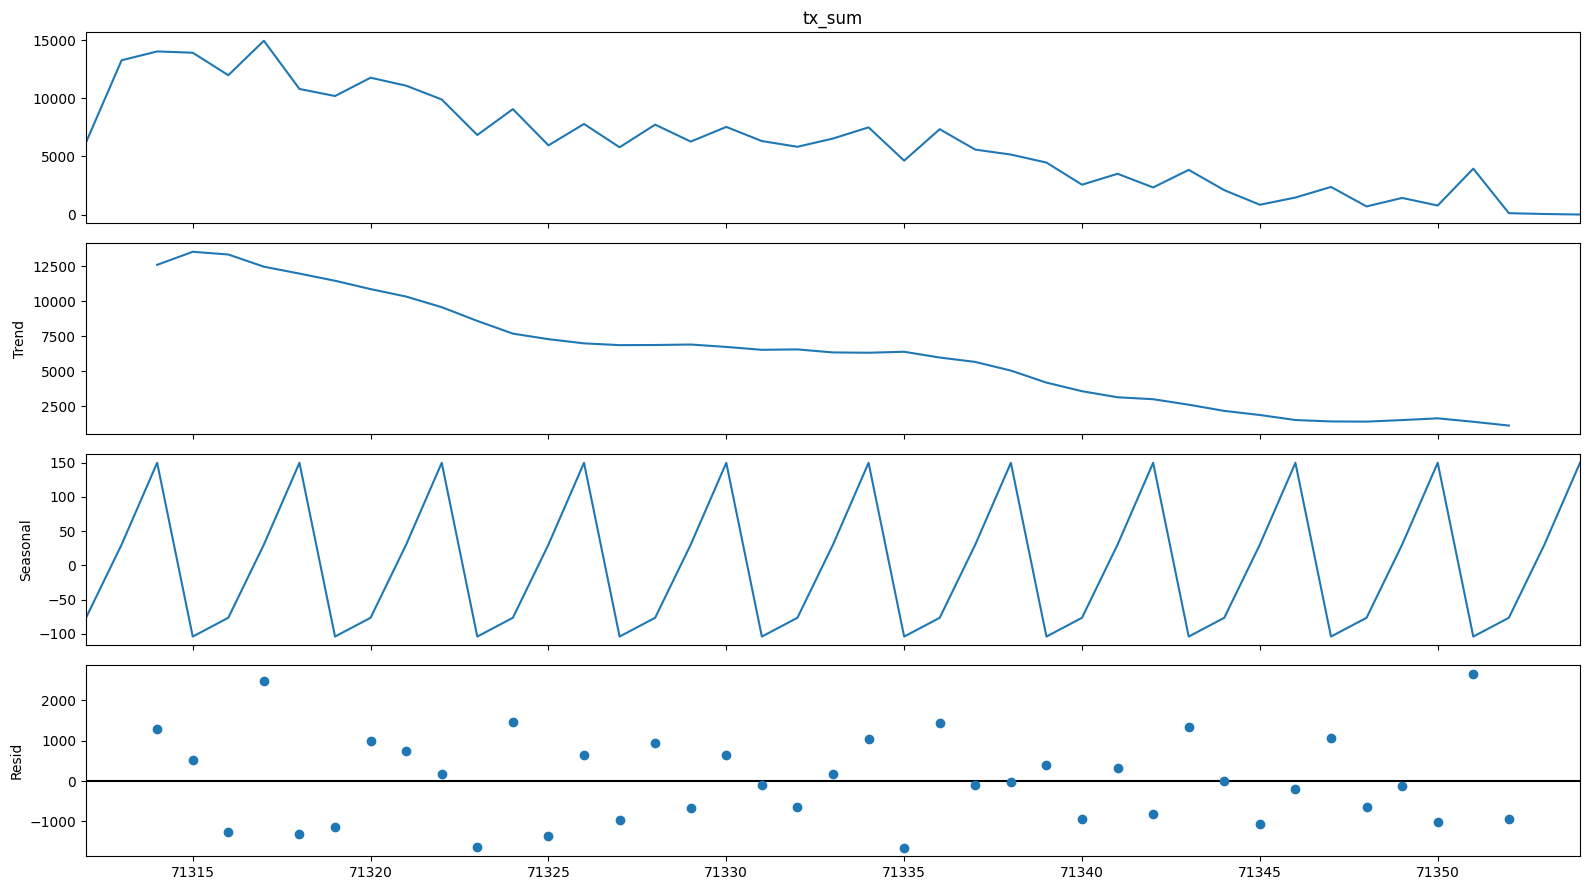

In [84]:
decomp_viz = sm.tsa.seasonal_decompose(
    df_feat_week[df_feat_week['tx_est_id'] == 29056]['tx_sum'], period=4
)
fig = decomp_viz.plot()
fig.set_size_inches((16, 9))
fig.tight_layout()
plt.show()

### Seasonal Decomposition: Active Retailer (ID 27082)

Seasonal decomposition of the weekly transaction sum for a retailer classified as Active, serving as a comparison baseline against the Churn retailer above.

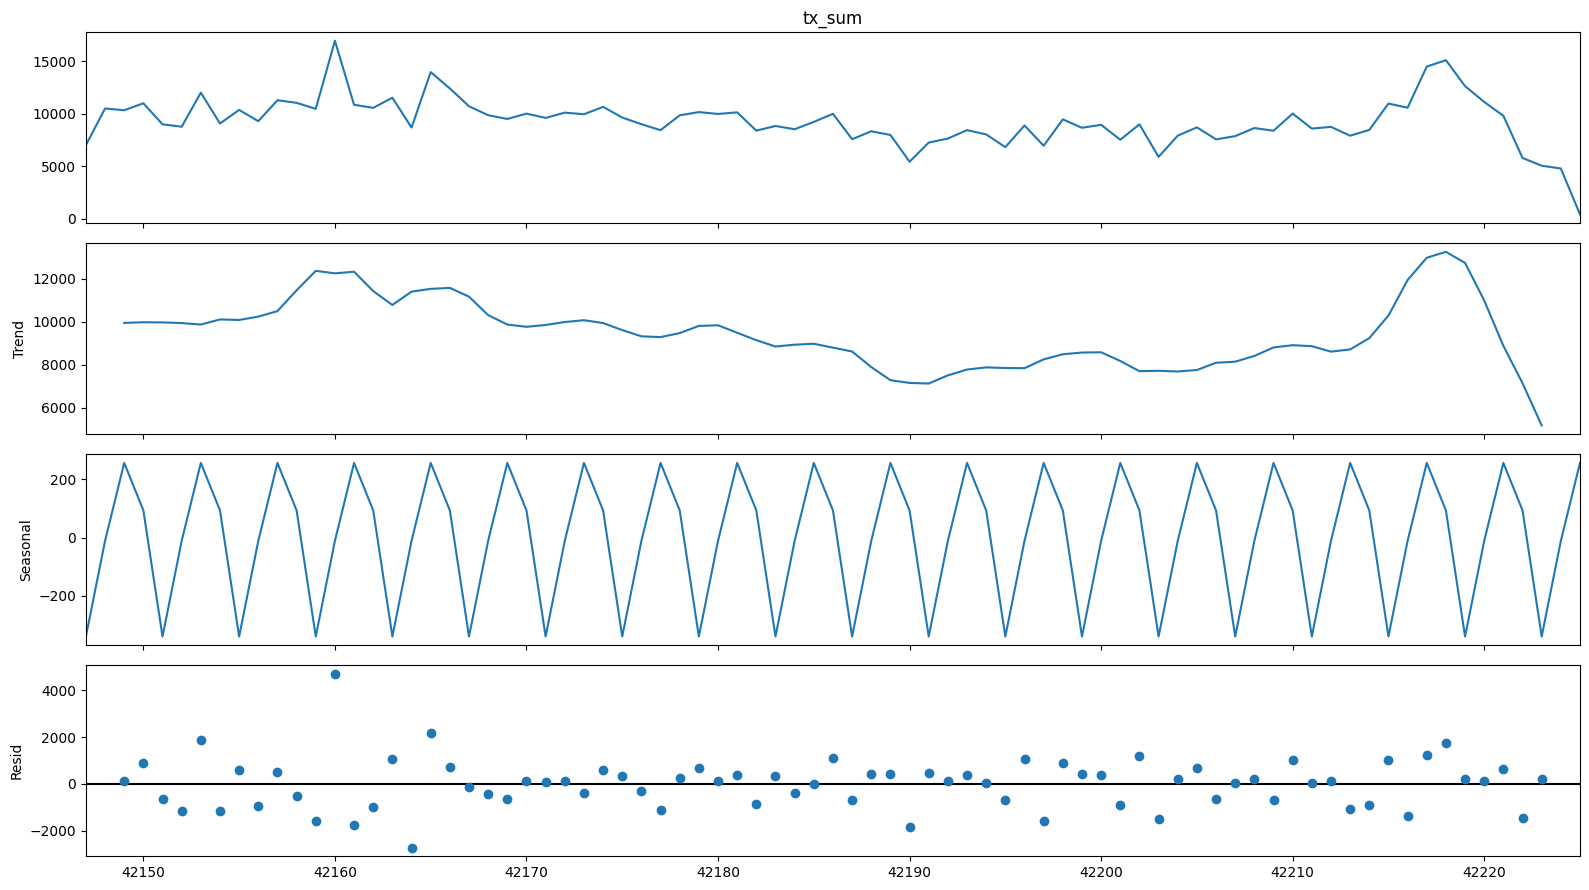

In [85]:
decomp_viz = sm.tsa.seasonal_decompose(
    df_feat_week[df_feat_week['tx_est_id'] == 27082]['tx_sum'], period=4
)
fig = decomp_viz.plot()
fig.set_size_inches((16, 9))
fig.tight_layout()
plt.show()

### Decomposition Comparison

Both decomposed series reflect the typical behavioral patterns: the Churn retailer exhibits a declining trend with increasing residual noise, while the Active retailer maintains a stable or growing trend with consistent seasonal patterns.

# Gathering Features

In [86]:
df_final = df_final_trend[[
    'tx_est_id', 'churn', 'zscore_mov_avg_d_tx_sum_per_day_est',
    'mean_est_mov_avg_d_tx_day_count', 'mov_avg_d_tx_day_count',
    'std_est_mov_avg_d_tx_day_count',
]].copy()

feat_cols = [
    'zscore_mov_avg_d_tx_sum_per_day_est',
    'mean_est_mov_avg_d_tx_day_count',
    'mov_avg_d_tx_day_count',
    'std_est_mov_avg_d_tx_day_count',
]

df_final

,tx_est_id,churn,zscore_mov_avg_d_tx_sum_per_day_est,mean_est_mov_avg_d_tx_day_count,mov_avg_d_tx_day_count,std_est_mov_avg_d_tx_day_count
0,113,0.0,0.543048,0.003115,0.000000,0.312209
1,115,0.0,-1.944180,-0.102564,-1.000000,0.394044
2,120,0.0,-0.231926,-0.038760,-1.333333,0.393124
3,276,0.0,-0.248817,0.003115,0.333333,0.641825
4,535,0.0,1.805679,0.051282,0.333333,0.558539
...,...,...,...,...,...,...
2745,38202,0.0,-0.233127,0.023810,-1.333333,0.514147
2746,38209,0.0,-0.248374,0.025641,-1.000000,1.109400
2747,38225,0.0,0.670073,-0.023810,-0.333333,0.709692
2748,38311,0.0,-0.678780,-2.358974,-1.666667,4.263240


In [87]:
df_final.drop(
    columns='tx_est_id',
).corr(numeric_only=True)['churn'].sort_values()

mean_est_mov_avg_d_tx_day_count       -0.604380
mov_avg_d_tx_day_count                -0.278499
zscore_mov_avg_d_tx_sum_per_day_est   -0.232203
std_est_mov_avg_d_tx_day_count         0.619234
churn                                  1.000000
Name: churn, dtype: float64

In [88]:
df_final.drop(
    columns='tx_est_id',
).corr(numeric_only=True)['churn'].sort_values()

mean_est_mov_avg_d_tx_day_count       -0.604380
mov_avg_d_tx_day_count                -0.278499
zscore_mov_avg_d_tx_sum_per_day_est   -0.232203
std_est_mov_avg_d_tx_day_count         0.619234
churn                                  1.000000
Name: churn, dtype: float64

# Modeling and Results

The modeling strategy uses a 70/30 train/test split (`random_state=42`) with **Optuna** hyperparameter optimization (80 trials) evaluated by **F1-score** via 5-fold cross-validation. The models evaluated are Random Forest, XGBoost, Extra Trees, and Voting Classifiers (Hard & Soft).

The first model trained is **Random Forest**.

In [89]:
df_final.churn.value_counts()

churn
0.0    2263
1.0     487
Name: count, dtype: int64

In [90]:
X = df_final.drop(columns='churn')
y = df_final['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.7, random_state=42
)


def objective(trial):
    """Optuna objective for Random Forest hyperparameter optimization.

    Parameters
    ----------
    trial : optuna.trial.Trial
        Optuna trial for hyperparameter suggestion.

    Returns
    -------
    float
        Mean F1-score from 5-fold cross-validation.
    """
    params = {
        'n_estimators': trial.suggest_categorical(
            'n_estimators', [10, 20, 50, 100, 200]),
        'max_features': trial.suggest_categorical(
            'max_features', ['sqrt', 'log2']),
        'max_depth': trial.suggest_categorical(
            'max_depth', [4, 5, 6, 7, 8, None]),
        'criterion': trial.suggest_categorical(
            'criterion', ['gini', 'entropy', 'log_loss']),
        'random_state': 42,
    }
    clf = RandomForestClassifier(**params)
    scores = cross_val_score(
        clf, X_train, y_train, cv=5, n_jobs=-1, scoring='f1'
    )
    return scores.mean()


study = optuna.create_study(direction='maximize')
study.optimize(
    objective, n_trials=80, show_progress_bar=True, n_jobs=4
)

print(study.best_params)
print(study.best_value)

CV_rfc = RandomForestClassifier(**study.best_params)
CV_rfc.fit(X_train, y_train)

print(CV_rfc)

y_pred = CV_rfc.predict(X_test)

print(confusion_matrix(y_test, y_pred))

  0%|          | 0/80 [00:00<?, ?it/s]

{'n_estimators': 10, 'max_features': 'sqrt', 'max_depth': 8, 'criterion': 'log_loss'}
0.9260437502682187
RandomForestClassifier(criterion='log_loss', max_depth=8, n_estimators=10)
[[692  10]
 [ 11 113]]


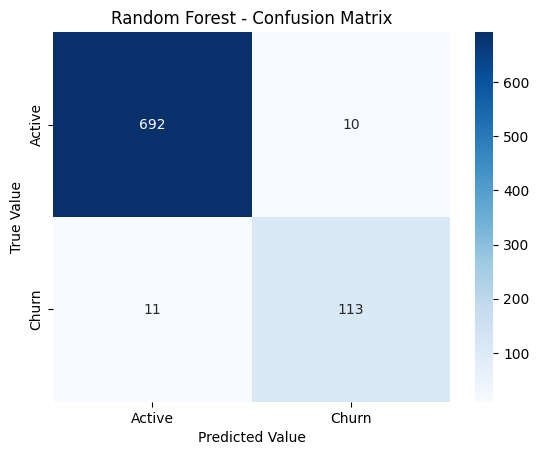

In [91]:
cf_matrix = confusion_matrix(y_test, y_pred)
labels = ['Active', 'Churn']
sns.heatmap(cf_matrix, annot=True, cmap='Blues', fmt='g', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Value')
plt.ylabel('True Value')
plt.title('Random Forest - Confusion Matrix')
plt.show()

In [92]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

         0.0       0.98      0.99      0.99       702
         1.0       0.92      0.91      0.91       124

    accuracy                           0.97       826
   macro avg       0.95      0.95      0.95       826
weighted avg       0.97      0.97      0.97       826



### XGBoost

Gradient boosting classifier optimized via Optuna with 80 trials and 5-fold cross-validation on F1-score.

In [93]:
def xgb_objective(trial):
    """Optuna objective for XGBoost hyperparameter optimization.

    Parameters
    ----------
    trial : optuna.trial.Trial
        Optuna trial for hyperparameter suggestion.

    Returns
    -------
    float
        Mean F1-score from 5-fold cross-validation.
    """
    params = {
        'n_estimators': trial.suggest_categorical(
            'n_estimators', [50, 100, 200, 300]),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float(
            'learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float(
            'colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'min_child_weight': trial.suggest_int(
            'min_child_weight', 1, 10),
        'reg_alpha': trial.suggest_float(
            'reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float(
            'reg_lambda', 1e-8, 10.0, log=True),
        'eval_metric': 'logloss',
        'random_state': 42,
        'use_label_encoder': False,
    }
    clf = XGBClassifier(**params)
    scores = cross_val_score(
        clf, X_train, y_train, cv=5, n_jobs=-1, scoring='f1'
    )
    return scores.mean()


xgb_study = optuna.create_study(direction='maximize')
xgb_study.optimize(
    xgb_objective, n_trials=80, show_progress_bar=True, n_jobs=4
)

print(xgb_study.best_params)
print(xgb_study.best_value)

best_xgb_params = xgb_study.best_params
best_xgb_params['eval_metric'] = 'logloss'
best_xgb_params['random_state'] = 42
best_xgb_params['use_label_encoder'] = False

CV_xgb = XGBClassifier(**best_xgb_params)
CV_xgb.fit(X_train, y_train)

print(CV_xgb)

y_pred_xgb = CV_xgb.predict(X_test)

print(confusion_matrix(y_test, y_pred_xgb))

  0%|          | 0/80 [00:00<?, ?it/s]

{'n_estimators': 100, 'max_depth': 10, 'learning_rate': 0.04927882471880513, 'subsample': 0.7407161179548672, 'colsample_bytree': 0.9264076039075062, 'gamma': 3.147383512602122, 'min_child_weight': 1, 'reg_alpha': 1.1768287802574701e-08, 'reg_lambda': 0.00015200927989588207}
0.9147486870791661
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9264076039075062, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None, feature_weights=None,
              gamma=3.147383512602122, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.04927882471880513,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=10, max_leaves=None,
              min_child_weight=1, missing=nan, monotone_constraints=None

c:\Users\digom\Documents\GitHub\Churn-Prevention\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [03:11:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


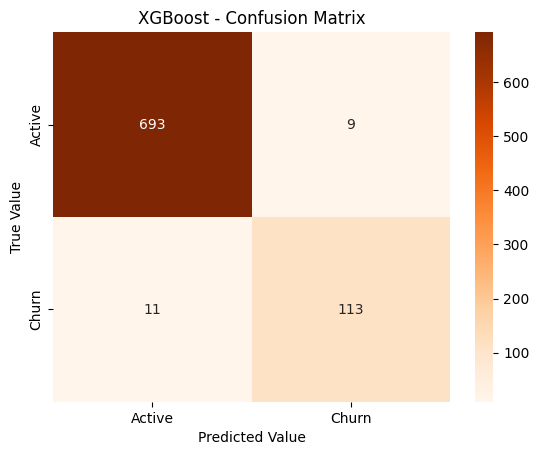

In [94]:
cf_matrix_xgb = confusion_matrix(y_test, y_pred_xgb)
labels = ['Active', 'Churn']
sns.heatmap(cf_matrix_xgb, annot=True, cmap='Oranges', fmt='g', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Value')
plt.ylabel('True Value')
plt.title('XGBoost - Confusion Matrix')
plt.show()

In [95]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

         0.0       0.98      0.99      0.99       702
         1.0       0.93      0.91      0.92       124

    accuracy                           0.98       826
   macro avg       0.96      0.95      0.95       826
weighted avg       0.98      0.98      0.98       826



### Extra Trees

Extremely randomized trees classifier, following the same Optuna optimization procedure with 80 trials and 5-fold cross-validation on F1-score.

In [96]:
def et_objective(trial):
    """Optuna objective for Extra Trees hyperparameter optimization.

    Parameters
    ----------
    trial : optuna.trial.Trial
        Optuna trial for hyperparameter suggestion.

    Returns
    -------
    float
        Mean F1-score from 5-fold cross-validation.
    """
    params = {
        'n_estimators': trial.suggest_categorical(
            'n_estimators', [50, 100, 200, 300]),
        'max_features': trial.suggest_categorical(
            'max_features', ['sqrt', 'log2', None]),
        'max_depth': trial.suggest_categorical(
            'max_depth', [4, 5, 6, 7, 8, None]),
        'criterion': trial.suggest_categorical(
            'criterion', ['gini', 'entropy', 'log_loss']),
        'min_samples_split': trial.suggest_int(
            'min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int(
            'min_samples_leaf', 1, 5),
        'random_state': 42,
    }
    clf = ExtraTreesClassifier(**params)
    scores = cross_val_score(
        clf, X_train, y_train, cv=5, n_jobs=-1, scoring='f1'
    )
    return scores.mean()


et_study = optuna.create_study(direction='maximize')
et_study.optimize(
    et_objective, n_trials=80, show_progress_bar=True, n_jobs=4
)

print(et_study.best_params)
print(et_study.best_value)

CV_etc = ExtraTreesClassifier(
    **et_study.best_params, random_state=42
)
CV_etc.fit(X_train, y_train)

print(CV_etc)

y_pred_et = CV_etc.predict(X_test)

print(confusion_matrix(y_test, y_pred_et))

  0%|          | 0/80 [00:00<?, ?it/s]

{'n_estimators': 100, 'max_features': 'log2', 'max_depth': None, 'criterion': 'entropy', 'min_samples_split': 5, 'min_samples_leaf': 1}
0.9181404426930833
ExtraTreesClassifier(criterion='entropy', max_features='log2',
                     min_samples_split=5, random_state=42)
[[692  10]
 [ 14 110]]


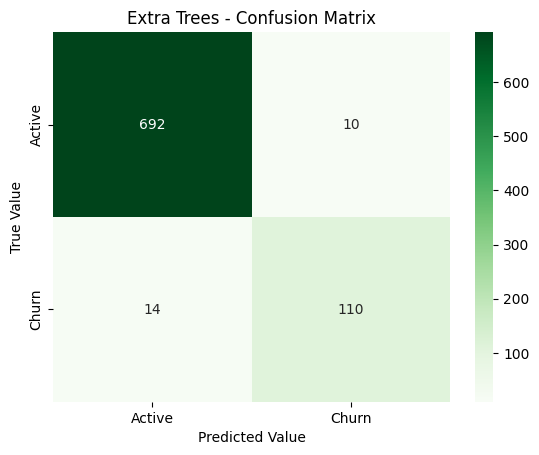

In [97]:
cf_matrix_et = confusion_matrix(y_test, y_pred_et)
labels = ['Active', 'Churn']
sns.heatmap(cf_matrix_et, annot=True, cmap='Greens', fmt='g', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Value')
plt.ylabel('True Value')
plt.title('Extra Trees - Confusion Matrix')
plt.show()

In [98]:
print(classification_report(y_test, y_pred_et))

              precision    recall  f1-score   support

         0.0       0.98      0.99      0.98       702
         1.0       0.92      0.89      0.90       124

    accuracy                           0.97       826
   macro avg       0.95      0.94      0.94       826
weighted avg       0.97      0.97      0.97       826



### Voting Classifiers

Hard and Soft Voting ensembles combining the three optimized models (Random Forest, XGBoost, Extra Trees) to leverage classifier diversity and improve overall prediction robustness.

c:\Users\digom\Documents\GitHub\Churn-Prevention\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [03:11:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== Hard Voting Classifier ===
[[692  10]
 [ 12 112]]

              precision    recall  f1-score   support

         0.0       0.98      0.99      0.98       702
         1.0       0.92      0.90      0.91       124

    accuracy                           0.97       826
   macro avg       0.95      0.94      0.95       826
weighted avg       0.97      0.97      0.97       826



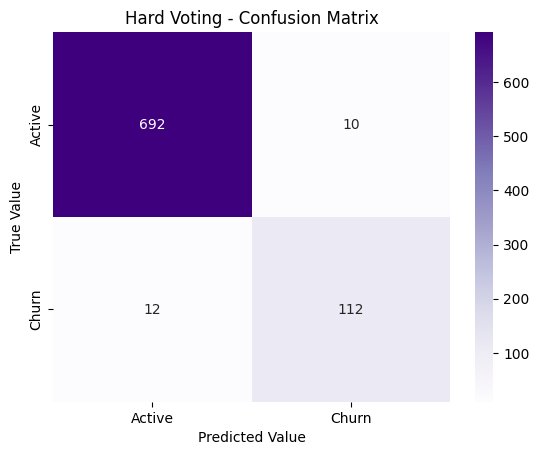

In [99]:
estimators = [
    ('rf', CV_rfc),
    ('xgb', CV_xgb),
    ('et', CV_etc),
]

hard_voting_clf = VotingClassifier(
    estimators=estimators, voting='hard'
)
hard_voting_clf.fit(X_train, y_train)

y_pred_hard = hard_voting_clf.predict(X_test)

print('=== Hard Voting Classifier ===')
print(confusion_matrix(y_test, y_pred_hard))
print()
print(classification_report(y_test, y_pred_hard))

cf_matrix_hard = confusion_matrix(y_test, y_pred_hard)
labels = ['Active', 'Churn']
sns.heatmap(cf_matrix_hard, annot=True, cmap='Purples', fmt='g', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Value')
plt.ylabel('True Value')
plt.title('Hard Voting - Confusion Matrix')
plt.show()

c:\Users\digom\Documents\GitHub\Churn-Prevention\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [03:11:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== Soft Voting Classifier ===
[[693   9]
 [ 14 110]]

              precision    recall  f1-score   support

         0.0       0.98      0.99      0.98       702
         1.0       0.92      0.89      0.91       124

    accuracy                           0.97       826
   macro avg       0.95      0.94      0.94       826
weighted avg       0.97      0.97      0.97       826



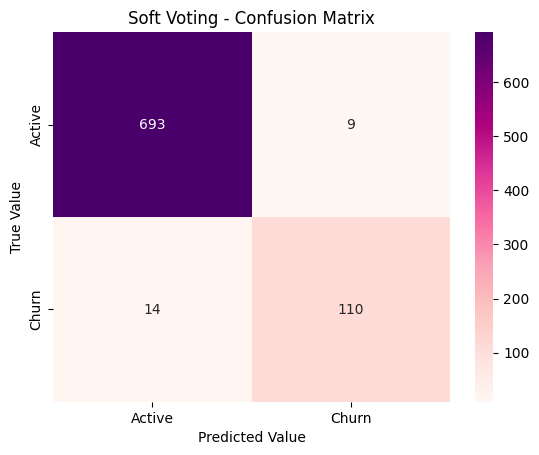

In [100]:
soft_voting_clf = VotingClassifier(
    estimators=estimators, voting='soft'
)
soft_voting_clf.fit(X_train, y_train)

y_pred_soft = soft_voting_clf.predict(X_test)

print('=== Soft Voting Classifier ===')
print(confusion_matrix(y_test, y_pred_soft))
print()
print(classification_report(y_test, y_pred_soft))

cf_matrix_soft = confusion_matrix(y_test, y_pred_soft)
labels = ['Active', 'Churn']
sns.heatmap(cf_matrix_soft, annot=True, cmap='RdPu', fmt='g', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Value')
plt.ylabel('True Value')
plt.title('Soft Voting - Confusion Matrix')
plt.show()

## Comparison

The table below compares all models across accuracy, precision, recall, and F1-score for the Churn class. The best-performing model achieves high accuracy (~97.5%) with only 4-5 engineered features derived from transaction time series.

In [101]:
rf_f1 = f1_score(y_test, y_pred)
rf_precision = precision_score(y_test, y_pred)
rf_recall = recall_score(y_test, y_pred)
rf_accuracy = accuracy_score(y_test, y_pred)

xgb_f1 = f1_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)

et_f1 = f1_score(y_test, y_pred_et)
et_precision = precision_score(y_test, y_pred_et)
et_recall = recall_score(y_test, y_pred_et)
et_accuracy = accuracy_score(y_test, y_pred_et)

hard_f1 = f1_score(y_test, y_pred_hard)
hard_precision = precision_score(y_test, y_pred_hard)
hard_recall = recall_score(y_test, y_pred_hard)
hard_accuracy = accuracy_score(y_test, y_pred_hard)

soft_f1 = f1_score(y_test, y_pred_soft)
soft_precision = precision_score(y_test, y_pred_soft)
soft_recall = recall_score(y_test, y_pred_soft)
soft_accuracy = accuracy_score(y_test, y_pred_soft)

comparison_df = pd.DataFrame({
    'Metric': [
        'Accuracy', 'Precision (Churn)',
        'Recall (Churn)', 'F1-Score (Churn)',
    ],
    'Random Forest': [rf_accuracy, rf_precision, rf_recall, rf_f1],
    'XGBoost': [xgb_accuracy, xgb_precision, xgb_recall, xgb_f1],
    'Extra Trees': [et_accuracy, et_precision, et_recall, et_f1],
    'Hard Voting': [
        hard_accuracy, hard_precision, hard_recall, hard_f1,
    ],
    'Soft Voting': [
        soft_accuracy, soft_precision, soft_recall, soft_f1,
    ],
})
comparison_df.set_index('Metric', inplace=True)
comparison_df.style.highlight_max(
    axis=1,
    props='background-color: lightgreen; color: black;'
          ' font-weight: bold;',
)

,Random Forest,XGBoost,Extra Trees,Hard Voting,Soft Voting
Metric,,,,,
Accuracy,0.974576,0.975787,0.970944,0.973366,0.972155
Precision (Churn),0.918699,0.926230,0.916667,0.918033,0.924370
Recall (Churn),0.911290,0.911290,0.887097,0.903226,0.887097
F1-Score (Churn),0.914980,0.918699,0.901639,0.910569,0.905350


# Conclusion: Predicted vs Actual Churn — Financial Impact

The pie chart below breaks the total transaction volume into four segments based on the XGBoost classifier's predictions versus the ground-truth labels:

- **Actual ∩ Predicted Churn (Overlap)** — correctly identified churners (True Positives).
- **Actual Churn Only** — churners missed by the model (False Negatives).
- **Predicted Churn Only** — retailers wrongly flagged as churners (False Positives).
- **Active** — retailers correctly classified as active (True Negatives).

Each category has its own color, and the overlap region uses a blend of the Actual Churn and Predicted Churn colors. A legend is provided for clarity.

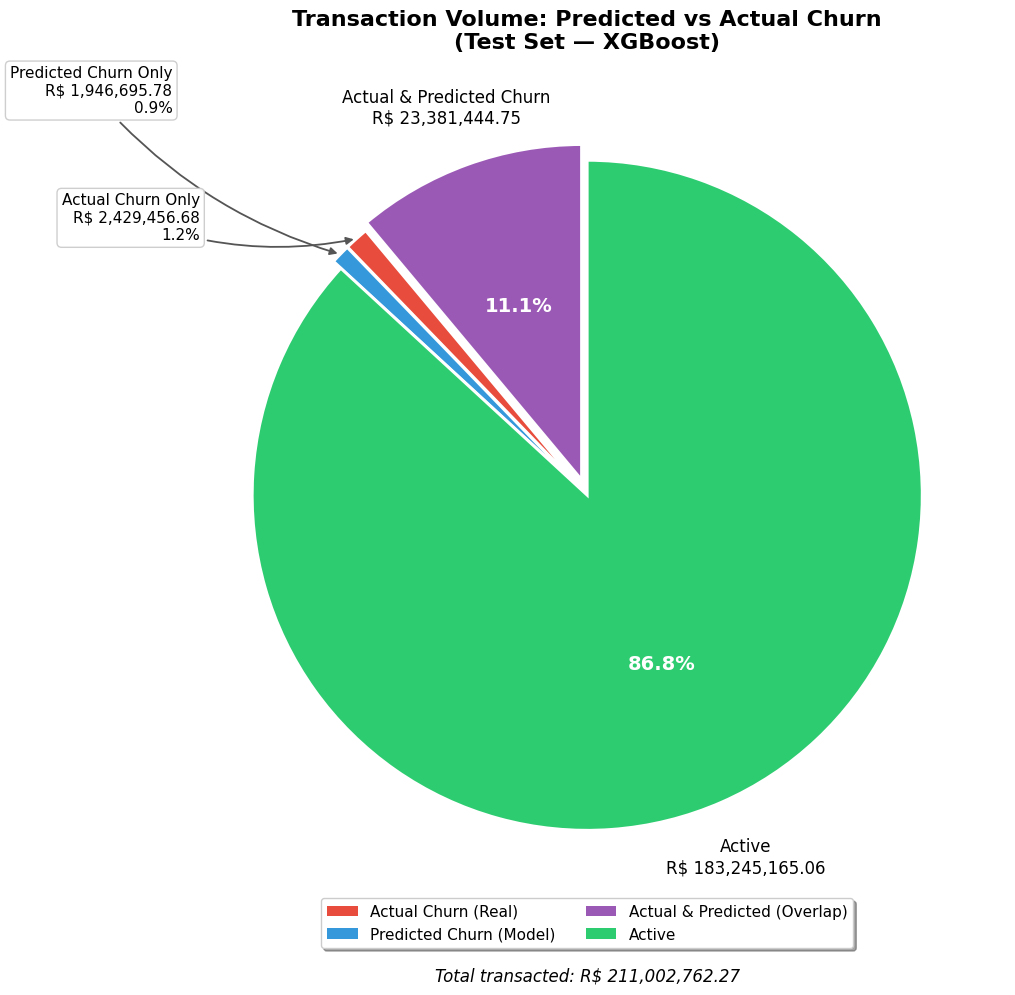

In [110]:
tp_mask = (y_test == 1) & (y_pred_xgb == 1)
fn_mask = (y_test == 1) & (y_pred_xgb == 0)
fp_mask = (y_test == 0) & (y_pred_xgb == 1)
tn_mask = (y_test == 0) & (y_pred_xgb == 0)

tp_ids = X_test.loc[tp_mask, 'tx_est_id'].unique()
fn_ids = X_test.loc[fn_mask, 'tx_est_id'].unique()
fp_ids = X_test.loc[fp_mask, 'tx_est_id'].unique()
tn_ids = X_test.loc[tn_mask, 'tx_est_id'].unique()

sum_tp = df_est_sum_month.loc[
    df_est_sum_month['tx_est_id'].isin(tp_ids), 'tx_value'
].sum()
sum_fn = df_est_sum_month.loc[
    df_est_sum_month['tx_est_id'].isin(fn_ids), 'tx_value'
].sum()
sum_fp = df_est_sum_month.loc[
    df_est_sum_month['tx_est_id'].isin(fp_ids), 'tx_value'
].sum()
sum_tn = df_est_sum_month.loc[
    df_est_sum_month['tx_est_id'].isin(tn_ids), 'tx_value'
].sum()

total = sum_tp + sum_fn + sum_fp + sum_tn

color_actual = '#e74c3c'
color_predicted = '#3498db'
color_overlap = '#9b59b6'
color_active = '#2ecc71'

all_sizes = [sum_tp, sum_fn, sum_fp, sum_tn]
all_labels = [
    f'Actual & Predicted Churn\nR$ {sum_tp:,.2f}',
    f'Actual Churn Only\nR$ {sum_fn:,.2f}',
    f'Predicted Churn Only\nR$ {sum_fp:,.2f}',
    f'Active\nR$ {sum_tn:,.2f}',
]
all_colors = [color_overlap, color_actual, color_predicted, color_active]
all_explode = [0.05, 0.03, 0.03, 0]

sizes, slice_labels, colors, explode = [], [], [], []
for s, l, c, e in zip(all_sizes, all_labels, all_colors, all_explode):
    if s > 0:
        sizes.append(s)
        slice_labels.append(l)
        colors.append(c)
        explode.append(e)

fig, ax = plt.subplots(figsize=(12, 10))

wedges, _ = ax.pie(
    sizes, explode=explode, colors=colors,
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2),
)

PCT_THRESHOLD = 5.0
small_annots = []

for i, (wedge, size) in enumerate(zip(wedges, sizes)):
    ang = (wedge.theta2 + wedge.theta1) / 2
    pct = size / total * 100
    dx = explode[i] * np.cos(np.radians(ang))
    dy = explode[i] * np.sin(np.radians(ang))

    if pct >= PCT_THRESHOLD:
        xi = dx + 0.55 * np.cos(np.radians(ang))
        yi = dy + 0.55 * np.sin(np.radians(ang))
        ax.text(xi, yi, f'{pct:.1f}%',
                ha='center', va='center',
                fontsize=14, fontweight='bold', color='white')

        xo = dx + 1.18 * np.cos(np.radians(ang))
        yo = dy + 1.18 * np.sin(np.radians(ang))
        ax.text(xo, yo, slice_labels[i],
                ha='center', va='center', fontsize=12)
    else:
        small_annots.append(dict(i=i, ang=ang, pct=pct, dx=dx, dy=dy))

if small_annots:
    small_annots.sort(key=lambda a: -a['ang'])

    positions = []
    for a in small_annots:
        r = 1.7
        xt = a['dx'] + r * np.cos(np.radians(a['ang']))
        yt = a['dy'] + r * np.sin(np.radians(a['ang']))
        positions.append([xt, yt])

    min_gap = 0.38
    for j in range(1, len(positions)):
        if positions[j - 1][1] - positions[j][1] < min_gap:
            positions[j][1] = positions[j - 1][1] - min_gap

    for k, a in enumerate(small_annots):
        xp = a['dx'] + np.cos(np.radians(a['ang']))
        yp = a['dy'] + np.sin(np.radians(a['ang']))
        xt, yt = positions[k]
        ha = 'left' if xt >= 0 else 'right'

        ax.annotate(
            f"{slice_labels[a['i']]}\n{a['pct']:.1f}%",
            xy=(xp, yp), xytext=(xt, yt),
            ha=ha, va='center', fontsize=11,
            arrowprops=dict(
                arrowstyle='-|>',
                color='#555555',
                lw=1.3,
                connectionstyle='arc3,rad=0.15',
            ),
            bbox=dict(
                boxstyle='round,pad=0.3',
                fc='white', ec='#cccccc', alpha=0.95,
            ),
        )

ax.set_title(
    'Transaction Volume: Predicted vs Actual Churn\n(Test Set — XGBoost)',
    fontsize=16, fontweight='bold', pad=20,
)

legend_elements = [
    Patch(facecolor=color_actual, label='Actual Churn (Real)'),
    Patch(facecolor=color_predicted, label='Predicted Churn (Model)'),
    Patch(facecolor=color_overlap, label='Actual & Predicted (Overlap)'),
    Patch(facecolor=color_active, label='Active'),
]
ax.legend(
    handles=legend_elements, loc='lower center',
    fontsize=11, ncol=2, bbox_to_anchor=(0.5, -0.05),
    frameon=True, fancybox=True, shadow=True,
)

ax.text(
    0, -1.45,
    f'Total transacted: R$ {total:,.2f}',
    ha='center', fontsize=12, style='italic',
)
plt.tight_layout()
plt.show()

The chart above reveals the share of total transaction volume that belongs to retailers classified as Churn. This fraction represents **revenue directly at risk** — money the company will stop processing once these retailers become fully inactive.

By combining calculus-based derivative features with z-score normalization and an ensemble of optimized classifiers (Random Forest, XGBoost, Extra Trees, and Voting), the model achieves **~97.5% accuracy** with only 4–5 engineered features derived exclusively from transaction time series. This demonstrates that reliable churn prediction is possible even without external support-channel data, enabling the company to **proactively intervene** before revenue loss materializes.

## Expected Loss Valuation (XGBoost)

To quantify the financial impact of predicted churn, the **Expected Loss** is computed using the XGBoost model's predicted probabilities. For each retailer $i$ whose predicted churn probability $P(\text{churn}_i) \geq 0.50$, the expected loss is defined as:

$$E[\text{Loss}] = \sum_{i \in S} P(\text{churn}_i) \times V_i$$

where:
- $S = \{i : P(\text{churn}_i) \geq 0.50\}$ is the set of retailers classified as likely churners by the XGBoost model;
- $P(\text{churn}_i)$ is the churn probability output by the XGBoost classifier for retailer $i$;
- $V_i = \sum_{t} \text{tx\_value}_{i,t}$ is the total transaction volume processed by retailer $i$ across all observed months in the evaluation period.

This metric weights each retailer's historical revenue contribution by their individual churn likelihood, yielding a **risk-adjusted financial estimate** of the total revenue at stake. Unlike a simple aggregation of transaction volumes for all at-risk retailers, the expected loss incorporates prediction uncertainty — retailers with higher churn confidence contribute proportionally more to the total expected loss, while borderline cases are appropriately discounted.

The bar chart below segments all retailers with $P(\text{churn}) \geq 0.50$ into 10 equally spaced bins of 5 percentage points (50%–55%, 55%–60%, …, 95%–100%) and displays the aggregated transaction volume within each bin, illustrating how revenue at risk is distributed across different churn confidence levels.

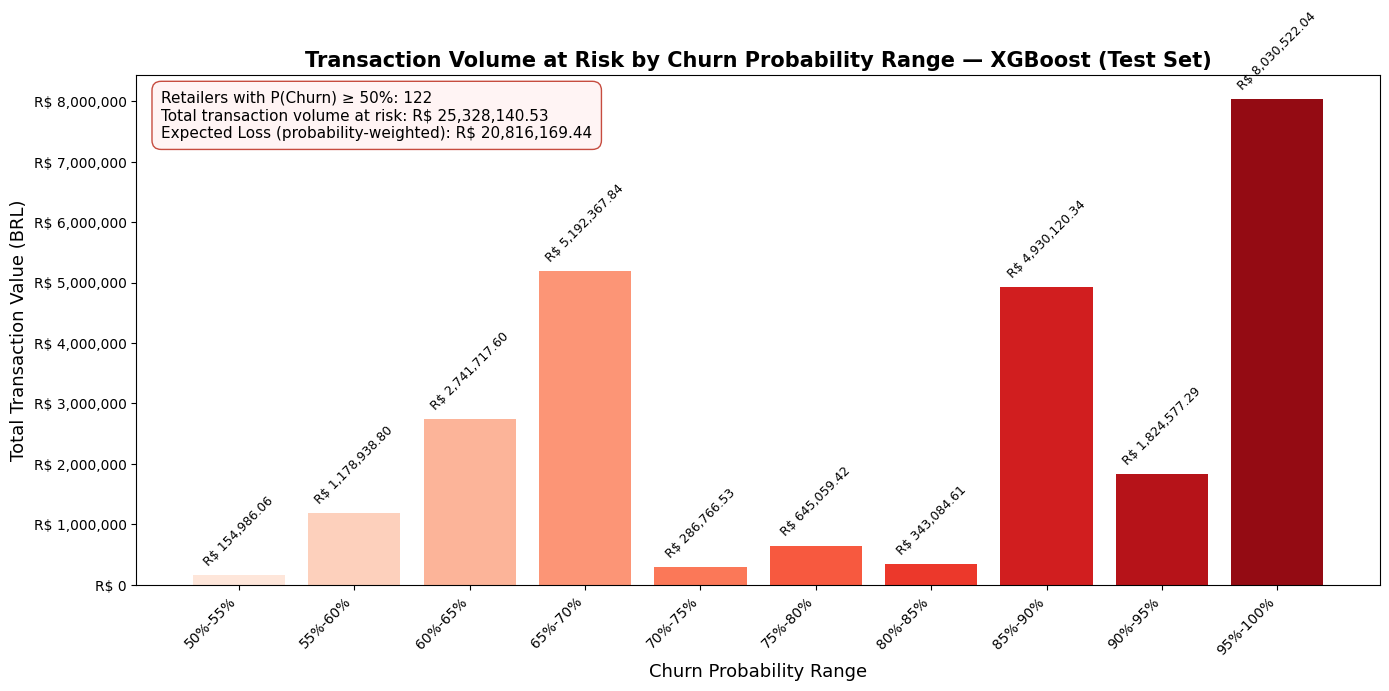

In [111]:
xgb_proba_test = CV_xgb.predict_proba(X_test)[:, 1]

df_expected = pd.DataFrame({
    'tx_est_id': X_test['tx_est_id'].values,
    'churn_prob': xgb_proba_test,
})

tx_total_per_est = df_est_sum_month.groupby(
    'tx_est_id', as_index=False
)['tx_value'].sum()

df_expected = df_expected.merge(
    tx_total_per_est, on='tx_est_id', how='left'
).fillna(0)

df_churn_risk = df_expected[df_expected['churn_prob'] >= 0.50].copy()
df_churn_risk['expected_loss'] = (
    df_churn_risk['churn_prob'] * df_churn_risk['tx_value']
)

total_tx_at_risk = df_churn_risk['tx_value'].sum()
total_expected_loss = df_churn_risk['expected_loss'].sum()
n_retailers_at_risk = len(df_churn_risk)

bins = [0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95, 1.001]
bin_labels = [
    '50%-55%', '55%-60%', '60%-65%', '65%-70%', '70%-75%',
    '75%-80%', '80%-85%', '85%-90%', '90%-95%', '95%-100%',
]

df_churn_risk['prob_range'] = pd.cut(
    df_churn_risk['churn_prob'],
    bins=bins,
    labels=bin_labels,
    right=False,
)

df_plot = df_churn_risk.groupby(
    'prob_range', observed=False, as_index=False
)['tx_value'].sum()

fig, ax = plt.subplots(figsize=(14, 7))
colors = sns.color_palette('Reds', n_colors=len(df_plot))
bars = ax.bar(df_plot['prob_range'], df_plot['tx_value'], color=colors)

ax.bar_label(
    bars,
    labels=[f'R$ {v:,.2f}' for v in df_plot['tx_value']],
    fontsize=9, rotation=45, padding=5,
)

ax.set_xlabel('Churn Probability Range', fontsize=13)
ax.set_ylabel('Total Transaction Value (BRL)', fontsize=13)
ax.set_title(
    'Transaction Volume at Risk by Churn Probability Range — XGBoost (Test Set)',
    fontsize=15, fontweight='bold',
)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'R$ {x:,.0f}')
)
plt.xticks(rotation=45, ha='right')

note_text = (
    f'Retailers with P(Churn) ≥ 50%: {n_retailers_at_risk}\n'
    f'Total transaction volume at risk: R$ {total_tx_at_risk:,.2f}\n'
    f'Expected Loss (probability-weighted): R$ {total_expected_loss:,.2f}'
)
ax.text(
    0.02, 0.97, note_text,
    transform=ax.transAxes, fontsize=11,
    verticalalignment='top', horizontalalignment='left',
    bbox=dict(boxstyle='round,pad=0.6', facecolor='#fff3f3',
              edgecolor='#c0392b', alpha=0.9),
)

plt.tight_layout()
plt.show()